# 06 — Análise de viés nos dados

Nuvem de palavras dos termos que aparecem nos títulos dos cursos do Coursera. Serve para enxergar onde o catálogo concentra sua oferta — áreas com poucos cursos vão receber pouca atenção do recomendador, independente do algoritmo escolhido.

In [1]:
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

In [2]:
courses = pd.read_csv('../data/Coursera_courses.csv')
courses.head()

,name,institution,course_url,course_id
0,Machine Learning,Stanford University,https://www.coursera.org/learn/machine-learning,machine-learning
1,Indigenous Canada,University of Alberta,https://www.coursera.org/learn/indigenous-canada,indigenous-canada
2,The Science of Well-Being,Yale University,https://www.coursera.org/learn/the-science-of-...,the-science-of-well-being
3,Technical Support Fundamentals,Google,https://www.coursera.org/learn/technical-suppo...,technical-support-fundamentals
4,Become a CBRS Certified Professional Installer...,Google - Spectrum Sharing,https://www.coursera.org/learn/google-cbrs-cpi...,google-cbrs-cpi-training


## Limpeza e stop words

Stop words padrão do inglês mais uma lista de termos genéricos do contexto educacional (course, introduction, fundamentals, capstone). Esses termos aparecem em quase todo título e abafariam o sinal temático.

In [3]:
# Stop words específicas do domínio educacional
domain_stopwords = {
    'course', 'courses', 'specialization', 'specialisation', 'professional',
    'certificate', 'certification', 'introduction', 'introductory', 'intro',
    'fundamental', 'fundamentals', 'basic', 'basics', 'beginner', 'beginners',
    'advanced', 'intermediate', 'essentials', 'essential', 'principles',
    'overview', 'guide', 'tutorial', 'learning', 'learn', 'study', 'studies',
    'understanding', 'concepts', 'concept', 'theory', 'practice', 'practical',
    'applied', 'application', 'applications', 'using', 'use', 'part',
    'level', 'getting', 'started', 'start', 'first', 'second', 'third',
    'one', 'two', 'three', 'four', 'five', 'i', 'ii', 'iii', 'iv', 'v',
    'new', 'modern', 'complete', 'comprehensive', 'master', 'masterclass',
    'project', 'projects', 'skills', 'skill', 'tools', 'tool', 'methods',
    'topics', 'topic', 'analysis', 'approach', 'approaches', 'foundations',
    'foundation', 'capstone', 'final', 'review', 'overview', 'al',
    'de', 'la', 'el', 'en', 'y', 'para', 'con', 'del', 'los', 'las', 'un', 'una',
}
stopwords = set(STOPWORDS) | domain_stopwords

In [4]:
def tokenize(text):
    text = str(text).lower()
    # mantém apenas letras (remove números, pontuação, símbolos)
    tokens = re.findall(r"[a-zA-Z]+", text)
    return [t for t in tokens if len(t) > 2 and t not in stopwords]

all_tokens = []
for name in courses['name'].dropna():
    all_tokens.extend(tokenize(name))

freq = Counter(all_tokens)
print(f'Total de tokens: {len(all_tokens):,}')
print(f'Vocabulário único: {len(freq):,}')
print('\nTop 30 termos:')
for term, count in freq.most_common(30):
    print(f'  {term:<20} {count}')

Total de tokens: 2,060
Vocabulário único: 1,044

Top 30 termos:
  data                 51
  management           30
  python               28
  science              25
  business             22
  health               19
  design               18
  machine              17
  international        17
  programming          16
  cloud                16
  law                  16
  google               15
  social               15
  financial            14
  global               14
  excel                13
  development          13
  digital              13
  marketing            12
  analytics            12
  english              11
  thinking             10
  world                9
  strategy             9
  models               9
  language             8
  human                8
  accounting           8
  managing             8


## Nuvem de palavras

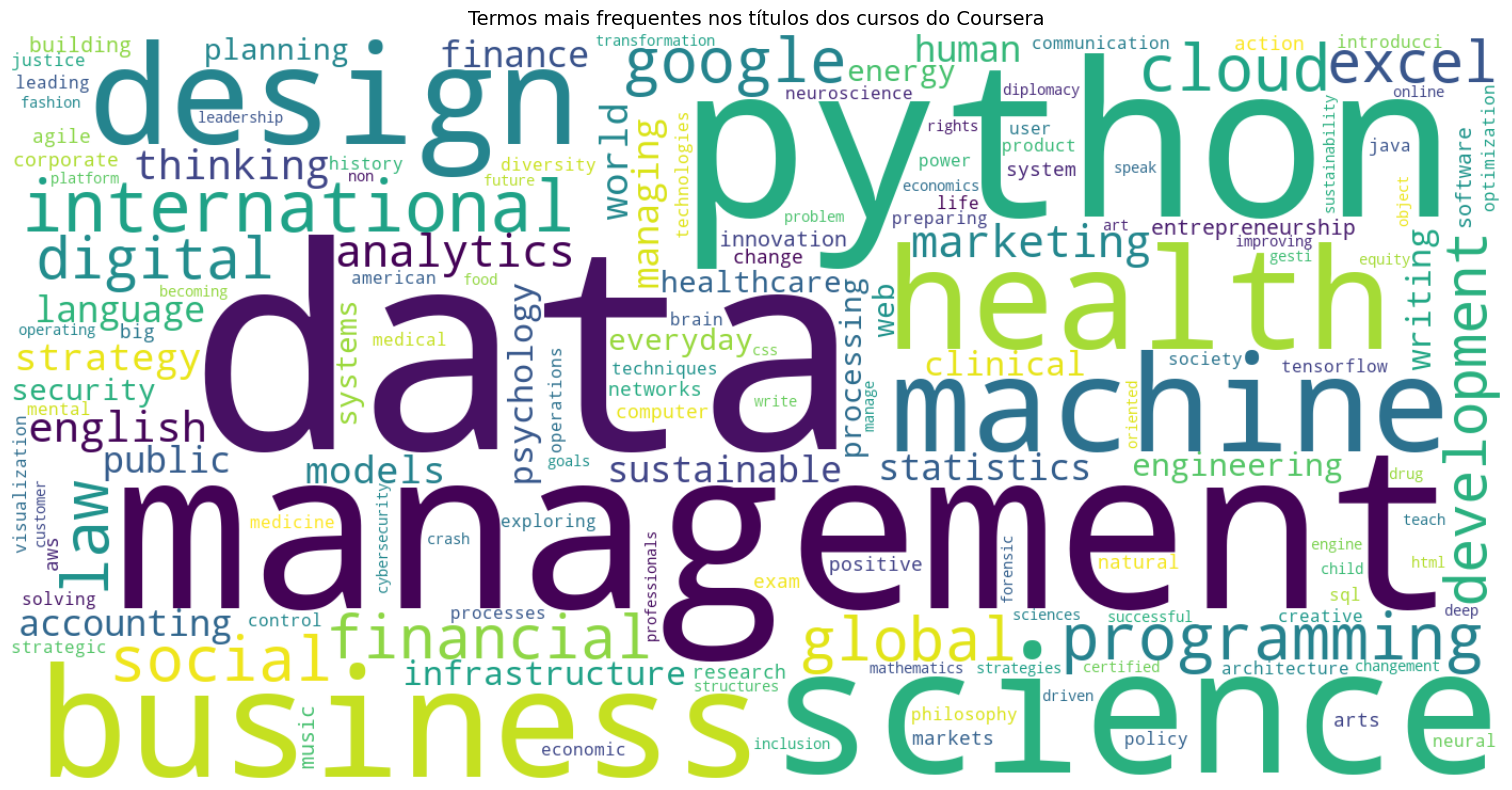

In [5]:
wc = WordCloud(
    width=1400,
    height=700,
    background_color='white',
    colormap='viridis',
    max_words=150,
    relative_scaling=0.5,
    prefer_horizontal=0.9,
).generate_from_frequencies(freq)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Termos mais frequentes nos títulos dos cursos do Coursera', fontsize=14)
plt.tight_layout()
plt.show()

## Leitura

`data` lidera com folga (51 ocorrências), seguido por management, python, science e business. O catálogo do Coursera pende fortemente para tecnologia, dados e gestão. Áreas como saúde, direito e idiomas existem, mas em volume bem menor — qualquer recomendador treinado nesse catálogo vai herdar esse desequilíbrio.